# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r = 0.25$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [ ]:
!pip install diffrax

In [ ]:
!unzip opalg

In [1]:
import json
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
import jax.numpy as jnp

import numpy as np
import tqdm
import matplotlib.pyplot as plt

import diffrax as dfx

from ybsoc import *

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [2]:
sim_num = 5

In [3]:
DATA_ROOT = f'/content/drive/MyDrive/YbSOC_PA_DATA/fig_2_loss/sim_{sim_num}'
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [4]:
L = 12
N = 4

hbar = 1.

m_Yb = 1.

# q = 1.
# delta = 1.5486
# omega_R = 1.0585

k = 0.
delta = 0.
omega_R = 0.

gamma = 0.36
d = 2 * (2 * jnp.pi) / L

system = YbSOC2bodyLoss(
    d=d,
    lengths=[L,],
    n_particle=N,
    hbar=hbar,
    q=k,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=gamma,
    array_type='numpy'
)

hamiltonian = system.dense_hamiltonian(
    display_progress=True
)

100%|██████████| 10626/10626 [00:03<00:00, 3097.17it/s]


## Initial State Preparation

In [5]:
n_points = 21
sim_range = (0, 0.8 / 0.1129)
ts = np.linspace(*sim_range, n_points)

In [6]:
def expmh(mat):
    W, Vt = np.linalg.eigh(mat)
    return np.einsum("...ij,...j,...jk->...ik", Vt.T.conj(), np.exp(W), Vt)

reduced_hamiltonian = np.array([
    [1.5486 / 2, 1.0585 / 2],
    [1.0585 / 2, -1.5486 / 2]
]) 
E, Vt = np.linalg.eigh(reduced_hamiltonian)
evo_operators = np.einsum("ij,nj,jk->nik", Vt.T.conj(), np.exp(-1j * E[None, :] * ts[:, None] / hbar), Vt)
alphas = evo_operators[:, 0, 0]
betas = evo_operators[:, 1, 0]

In [7]:
momentum_modes = (0, 1, 2, 11)

pure = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), 1),
        ((2,), 1),
        ((11,), 1),
    )
)

mixture = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), -1),
        ((2,), 1),
        ((11,), -1),
    )
)

# prob_up = 1 - 0.31844
# theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
# phi = 0

# alpha = np.cos(theta / 2)
# beta = np.exp(1j * phi) * np.sin(theta / 2)

alpha = alphas[sim_num]
beta = betas[sim_num]

spin_amps = {
    1: alpha,
    -1: beta
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=N):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        ((mode,), spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = system.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

In [8]:
def roll_array(numbers):
    L = numbers.shape[0]
    return np.roll(numbers, -(L + 1) // 2)

def plot_numbers(up_nums, down_nums, tick_labels=None, title=None, save_path=None, save_options=None):
    up_nums = roll_array(up_nums)
    down_nums = roll_array(down_nums)
    
    total_nums = up_nums + down_nums
    L = total_nums.shape[0]
    indices = np.arange(L) - (L // 2 - 1)
    
    bar_width = ((6 - 1) / L) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_nums, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_nums, bar_width, label='up')
    plt.bar(indices + bar_width/2, down_nums, bar_width, label='down')
    
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Expected numbers")
    plt.ylabel('$\\langle n\\rangle$')
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

def generate_k_labels(L):
    zero_index = (L - 1) // 2
    start_coeff = -zero_index * 0.5
    coeffs = [start_coeff + i * 0.5 for i in range(L)]
    result_list = []
    for c in coeffs:
        if c == 0:
            # 계수가 0일 경우
            formatted_str = "$0$"
        elif c == 1:
            # 계수가 1일 경우
            formatted_str = "$k_r$"
        elif c == -1:
            # 계수가 -1일 경우
            formatted_str = "$-k_r$"
        else:
            # 그 외의 경우 (정수 및 실수)
            # 계수가 2.0, -3.0과 같이 정수이면 소수점(.0)을 제거합니다.
            if c == int(c):
                num_str = str(int(c))
            else:
                num_str = str(c)
            formatted_str = f"${num_str}k_r$"
        result_list.append(formatted_str)
    return result_list
k_tick_labels = generate_k_labels(L)

In [9]:
# pure_numbers_up, pure_numbers_down = system.position_expected_numbers(pure)
# plot_numbers(pure_numbers_up, pure_numbers_down)

# pure_numbers_up, pure_numbers_down = system.position_expected_numbers(mixture)
# plot_numbers(pure_numbers_up, pure_numbers_down)

# pure_numbers_up, pure_numbers_down = system.position_expected_numbers(superposed)
# plot_numbers(pure_numbers_up, pure_numbers_down)

In [9]:
sigma = 1
def g(k):
    return np.exp(-np.vdot(k, k)/(4 * sigma ** 2))

In [10]:
gaussian_pure = np.zeros_like(pure)
for state_index, multi_particle_state in enumerate(system.multi_particle_states):
    amp = 1.0
    for midx, spin in multi_particle_state:
        if spin == -1:
            amp = 0
        else:
            k = system.momentums[system.site_to_index_map[midx]]
            amp *= g(k)
    gaussian_pure[state_index] = amp
gaussian_pure /= np.sqrt(np.vdot(gaussian_pure, gaussian_pure))

In [12]:
# pure_numbers_up, pure_numbers_down = system.position_expected_numbers(gaussian_pure)
# plot_numbers(pure_numbers_up, pure_numbers_down, title="Position Space Numbers")

# pure_numbers_up, pure_numbers_down = system.momentum_expected_numbers(gaussian_pure)
# plot_numbers(pure_numbers_up, pure_numbers_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

In [11]:
gaussian_mixture = np.zeros_like(pure)

def ferm_sign(spins):
    p = 0
    c = 0
    for i, s in enumerate(spins):
        if s == 1:
            c += 1
            p += i - c
    return 1 if p % 2 == 0 else -1

for state_index, multi_particle_state in enumerate(system.multi_particle_states):
    spins_in_state = tuple(spin for _, spin in multi_particle_state)
    if spins_in_state.count(1) != ((N + 1) // 2) or spins_in_state.count(-1) != (N // 2):
        continue
    amp = 1.0
    for midx, _ in multi_particle_state:
        k = system.momentums[system.site_to_index_map[midx]]
        amp *= g(k)
    amp *= ferm_sign(spins_in_state)
    gaussian_mixture[state_index] = amp
    
gaussian_mixture /= np.sqrt(np.vdot(gaussian_mixture, gaussian_mixture))

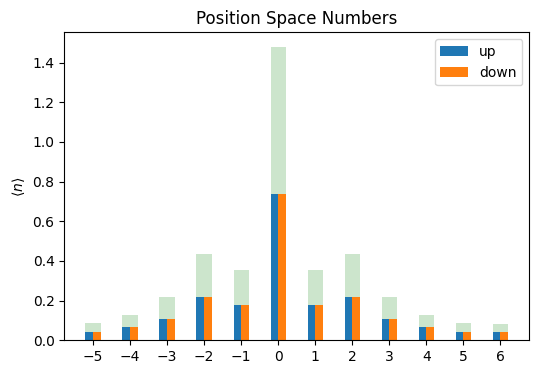

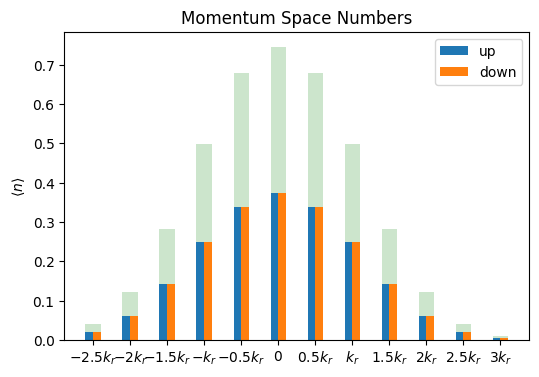

In [14]:
mixture_numbers_up, mixture_numbers_down = system.position_expected_numbers(gaussian_mixture)
plot_numbers(mixture_numbers_up, mixture_numbers_down, title="Position Space Numbers")

mixture_numbers_up, mixture_numbers_down = system.momentum_expected_numbers(gaussian_mixture)
plot_numbers(mixture_numbers_up, mixture_numbers_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

In [12]:
gaussian_superposed = np.zeros_like(pure)
for state_index, original_amp in enumerate(gaussian_pure):
    if abs(original_amp) < 1e-9:
        continue
    
    pure_up_fock_state = system.multi_particle_states[state_index]
    momentum_modes = [s[0] for s in pure_up_fock_state]
    for spin_config in itertools.product(spins, repeat=N):
        spin_amp_product = np.prod([spin_amps[s] for s in spin_config])
        final_amp = original_amp * spin_amp_product
        new_fock_state_config = tuple(
            (mode, spin) for mode, spin in zip(momentum_modes, spin_config)
        )
        new_idx = system.state_to_index_map_multi[new_fock_state_config]
        gaussian_superposed[new_idx] += final_amp

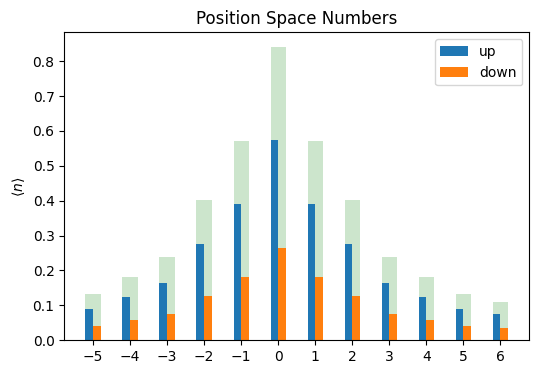

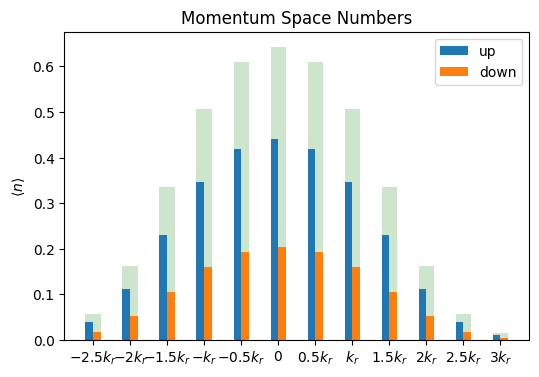

In [15]:
superposed_numbers_up, superposed_numbers_down = system.position_expected_numbers_optimized(gaussian_superposed)
plot_numbers(superposed_numbers_up, superposed_numbers_down, title="Position Space Numbers")

superposed_numbers_up, superposed_numbers_down = system.momentum_expected_numbers(gaussian_superposed)
plot_numbers(superposed_numbers_up, superposed_numbers_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

In [16]:
soc_system = YbSOCSystem(
    d=d,
    lengths=[L,],
    n_particle=N,
    hbar=hbar,
    q=1,
    m_Yb=m_Yb,
    delta=4,
    omega_R=3.5,
    U=0,
    array_type='numpy'
)

soc_hamiltonian = soc_system.dense_hamiltonian(
    display_progress=True
)

w, vt = np.linalg.eigh(soc_hamiltonian)

gs_energy = w[0]
soc_ground_state = vt[:, 0]

  0%|          | 0/10626 [00:00<?, ?it/s]

100%|██████████| 10626/10626 [00:02<00:00, 5185.96it/s]


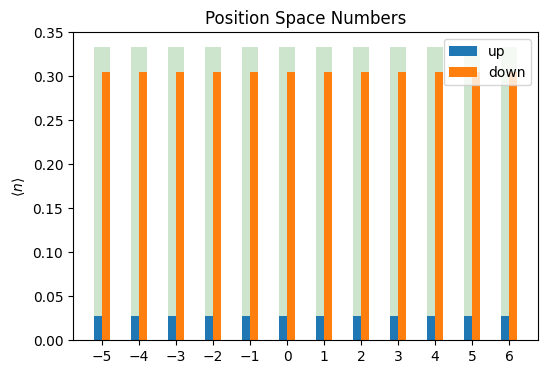

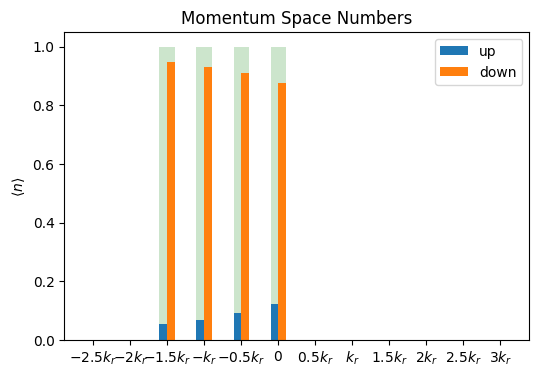

In [17]:
ground_state_numbers_up, ground_state_numbers_down = system.position_expected_numbers(soc_ground_state)
plot_numbers(ground_state_numbers_up, ground_state_numbers_down, title="Position Space Numbers")

ground_state_numbers_up, ground_state_numbers_down = system.momentum_expected_numbers(soc_ground_state)
plot_numbers(ground_state_numbers_up, ground_state_numbers_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

In [18]:
# temp = 0.4
# k_B = 1.
# beta = k_B / temp
# boltzmann_factors = np.exp(-beta * w)
# unnormalized_gibbs = np.einsum('k,ik,jk->ij', boltzmann_factors, vt, np.conj(vt))
# partition_function = np.sum(boltzmann_factors)
# gibbs_state = unnormalized_gibbs / partition_function

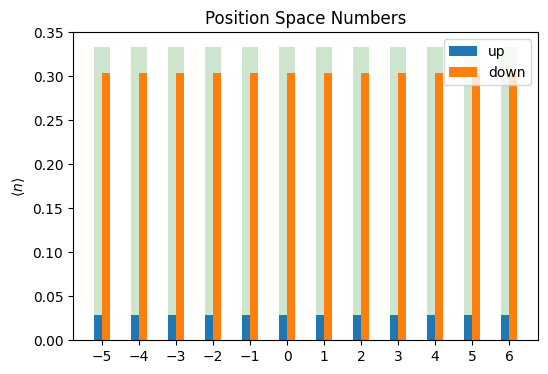

C:\Users\pco0511\AppData\Roaming\Python\Python312\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\pco0511\AppData\Roaming\Python\Python312\site-packages\matplotlib\transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
C:\Users\pco0511\AppData\Roaming\Python\Python312\site-packages\matplotlib\transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


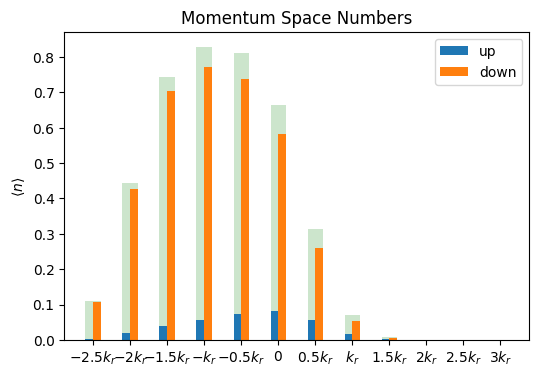

In [19]:
gibbs_state_numbers_up, gibbs_state_numbers_down = system.position_expected_numbers_mixed(gibbs_state)
plot_numbers(gibbs_state_numbers_up, gibbs_state_numbers_down, title="Position Space Numbers")

gibbs_state_numbers_up, gibbs_state_numbers_down = system.momentum_expected_numbers_mixed(gibbs_state)
plot_numbers(gibbs_state_numbers_up, gibbs_state_numbers_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

In [ ]:
# initial_state = pure
# initial_state = mixture
# initial_state = superposed

# initial_state = gaussian_pure
# initial_state = gaussian_mixture
# initial_state = gaussian_superposed

initial_state = soc_ground_state

: 

In [ ]:
initial_position_nums_up, initial_position_nums_down = system.position_expected_numbers(initial_state)
initial_momentum_nums_up, initial_momentum_nums_down = system.momentum_expected_numbers(initial_state)

plot_numbers(initial_position_nums_up, initial_position_nums_down, title="Position Space Numbers")
plot_numbers(initial_momentum_nums_up, initial_momentum_nums_down, tick_labels=k_tick_labels, title="Momentum Space Numbers")

## Simulation by exact propagator

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(hamiltonian)

In [ ]:
psi_tilde = np.linalg.solve(eigenvectors, initial_state)

t0 = 0
t1 = 0.8 / 0.1129
save_at = np.linspace(t0, t1, 101)
step_size = save_at[1] - save_at[0]

evolution_operator_diag = np.exp(-1j * eigenvalues * step_size / system.hbar)
psis = np.zeros((len(save_at), len(psi_tilde)), dtype=np.complex128)

psis[0, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
for i in tqdm.trange(len(save_at)):
    psis[i, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
    psi_tilde = evolution_operator_diag * psi_tilde

spin_up_numbers, spin_down_numbers = system.momentum_sp_expected_numbers_vectorized(psis)

In [ ]:
plt.figure(figsize=(6, 5))
t = save_at * 0.1129

# for i in range(8):
#     plt.plot(t, spin_up_numbers[:, i], label=f"$\\uparrow$, {i}")
#     plt.plot(t, spin_down_numbers[:, i], label=f"$\\downarrow$, {i}")

total_up = jnp.sum(spin_up_numbers, axis=1) / system.n_particle
total_down = jnp.sum(spin_down_numbers, axis=1) / system.n_particle

plt.plot(t, total_up, label="$\\uparrow$")
plt.plot(t, total_down, label="$\\downarrow$")
plt.plot(t, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

## ODE Integration

\begin{equation}
\frac{d\rho}{dt}=-\frac{i}{\hbar}\left[H\rho-\rho H^\dagger\right]-\operatorname{off-diagonal}(\rho)/T_2
\end{equation}

- $T_2 = 0.4 \,\mathrm{ms}$

In [ ]:
hamiltonian_jarr = jnp.array(hamiltonian, dtype=jnp.complex128)
initial_rho = jnp.outer(initial_state, initial_state.conj())      # |ψ〉〈ψ|

def drhodt(t, rho, args):
    (lam,) = args
    vne_term = (-1j / hbar) * (jnp.matmul(hamiltonian_jarr, rho) - jnp.matmul(rho, hamiltonian_jarr.T.conj()))
    decoherence_term = -lam * (rho - jnp.diag(jnp.diag(rho)))
    return vne_term + decoherence_term

term = dfx.ODETerm(drhodt)
solver = dfx.Dopri8()
saveat = dfx.SaveAt(ts=save_at)
stepsize_controller = dfx.PIDController(atol=1e-5, rtol=1e-5)

T2 = 0.52 / 0.1129

sol = dfx.diffeqsolve(
    term, solver, t0, t1, 1e-2, initial_rho, (1/T2,),
    saveat=saveat, stepsize_controller=stepsize_controller, max_steps=4096
)

rhos = sol.ys

In [ ]:
num_op_diag = jnp.array(system.momentum_sp_num_op_diags())

def numper_expectation(rho):
    expected_numbers = jnp.einsum('ij,jj->i', num_op_diag, rho)
    up_total = jnp.sum(expected_numbers[0::2]).item().real
    down_total = jnp.sum(expected_numbers[1::2]).item().real
    return up_total, down_total

total_up_decoherence = np.zeros((save_at.size,))
total_down_decoherence = np.zeros((save_at.size,))

for i in range(save_at.size):
    total_up_decoherence[i], total_down_decoherence[i] = numper_expectation(rhos[i])

total_up_decoherence /= system.n_particle
total_down_decoherence /= system.n_particle

In [ ]:
data_dir = os.path.join(DATA_ROOT, "data")
figs_dir = os.path.join(DATA_ROOT, "figs")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

In [ ]:
np.save(os.path.join(data_dir, "t.npy"), save_at)
np.save(os.path.join(data_dir, "up_no_decoherence.npy"), total_up)
np.save(os.path.join(data_dir, "down_no_decoherence.npy"), total_down)
np.save(os.path.join(data_dir, "up_decoherence.npy"), total_up_decoherence)
np.save(os.path.join(data_dir, "down_decoherence.npy"), total_down_decoherence)

with open(os.path.join(data_dir, "metadata.json"), "w+") as f:
    json.dump({
    "d": system.d,
    "lengths": system.lengths,
    "n_particle": system.n_particle,
    "hbar": system.hbar,
    "q": system.q.item(),
    "m_Yb": system.m_Yb,
    "delta": system.delta,
    "omega_R": system.omega_R,
    "gamma": system.gamma,
    "dim": system.dim,
    "k0": system.k0.item(),
    "T2": T2 * 0.1129 # ms
}, f, indent=4)

In [ ]:
# figure options
transparent = True
dpi = 300
save_options = {
    "transparent": transparent,
    "dpi": dpi
}

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 9))

ax1.plot(t, total_up, label="No decoherence")
ax1.plot(t, total_up_decoherence, label="T2 decoherence")
ax1.set_ylabel("$\\langle n_{\\uparrow} \\rangle$")
ax1.set_ylim(0, 1.1)
ax1.legend()

ax2.plot(t, total_down, label="No decoherence")
ax2.plot(t, total_down_decoherence, label="T2 decoherence")
ax2.set_ylabel("$\\langle n_{\\downarrow} \\rangle$")
ax2.set_ylim(0, 1.1)
ax2.legend()


ax3.plot(t, total_up + total_down, label="No decoherence")
ax3.plot(t, total_up_decoherence + total_down_decoherence, label="T2 decoherence")
ax3.set_ylabel("$\\langle n_{\\uparrow} \\rangle + \\langle n_{\\downarrow} \\rangle$")
ax3.set_ylim(0, 1.1)
ax3.legend()
ax3.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
fig_path = os.path.join(figs_dir, "total_number_time_evolution.png")
plt.savefig(fig_path, **save_options)
plt.show()

In [ ]:
final_position_nums_up, final_position_nums_down = system.position_expected_numbers(psis[-1])
final_momentum_nums_up, final_momentum_nums_down = system.momentum_expected_numbers(psis[-1])

np.save(os.path.join(data_dir, "final_position_numbers_up_no_deco.npy"), final_position_nums_up)
np.save(os.path.join(data_dir, "final_position_numbers_down_no_deco.npy"), final_position_nums_down)
np.save(os.path.join(data_dir, "total_momentum_numbers_up_no_deco.npy"), final_momentum_nums_up)
np.save(os.path.join(data_dir, "total_momentum_numbers_down_no_deco.npy"), final_momentum_nums_down)

fig_path = os.path.join(figs_dir, "final_position_numbers_no_deco.png")
plot_numbers(
    final_position_nums_up,
    final_position_nums_down,
    title="Final Position Space Numbers (no deco.)",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers_no_deco.png")
plot_numbers(
    final_momentum_nums_up,
    final_momentum_nums_down,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
final_position_nums_up_deco, final_position_nums_down_deco = system.position_expected_numbers_mixed(rhos[-1])
final_momentum_nums_up_deco, final_momentum_nums_down_deco = system.momentum_expected_numbers_mixed(rhos[-1])

np.save(os.path.join(data_dir, "final_position_nums_up_deco.npy"), final_position_nums_up_deco)
np.save(os.path.join(data_dir, "final_position_nums_down_deco.npy"), final_position_nums_down_deco)
np.save(os.path.join(data_dir, "final_momentum_nums_up_deco.npy"), final_momentum_nums_up_deco)
np.save(os.path.join(data_dir, "final_momentum_nums_down_deco.npy"), final_momentum_nums_down_deco)

fig_path = os.path.join(figs_dir, "final_position_numbers_deco.png")
plot_numbers(
    final_position_nums_up_deco,
    final_position_nums_down_deco,
    title="Final Position Space Numbers (deco.)",
    save_path=fig_path,
    save_options=save_options
)
fig_path = os.path.join(figs_dir, "total_momentum_numbers_deco.png")
plot_numbers(
    final_momentum_nums_up_deco,
    final_momentum_nums_down_deco,
    tick_labels=k_tick_labels,
    title="Final Momentum Space Numbers (deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
def plot_fractions(up_frac, down_frac, total_frac, tick_labels=None, title=None, save_path=None, save_options=None):
    up_frac = roll_array(up_frac)
    down_frac = roll_array(down_frac)
    total_frac = roll_array(total_frac)
    
    L = total_frac.shape[0]
    indices = np.arange(L) - (L // 2 - 1)
    
    bar_width = ((6 - 1) / L) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_frac, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_frac, bar_width, alpha=0.35, label='up')
    plt.bar(indices + bar_width/2, down_frac, bar_width, alpha=0.35, label='down')
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Fractions")
    plt.ylabel('$\\langle n\\rangle_\\text{final}/ \\langle n\\rangle_\\text{init}$')
    plt.ylim(-0.1, 1.1)
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

In [ ]:
def calc_loss_frac(initial, final):
    return np.where(np.abs(initial) < 1e-12, np.zeros_like(0), 1 - final / initial)

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total = final_position_nums_up + final_position_nums_down
final_momentum_nums_total = final_momentum_nums_up + final_momentum_nums_down

loss_fraction_up_position = calc_loss_frac(initial_position_nums_up, final_position_nums_up)
loss_fraction_down_position = calc_loss_frac(initial_position_nums_down, final_position_nums_down)
loss_fraction_total_position = calc_loss_frac(initial_position_nums_total, final_position_nums_total)

loss_fraction_up_momentum = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up)
loss_fraction_down_momentum = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down)
loss_fraction_total_momentum = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total)


fig_path = os.path.join(figs_dir, "position_space_loss_fraction_no_deco.png")
plot_fractions(
    loss_fraction_up_position,
    loss_fraction_down_position,
    loss_fraction_total_position,
    title="Position Space Loss Fractions (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction_no_deco.png")
plot_fractions(
    loss_fraction_up_momentum,
    loss_fraction_down_momentum,
    loss_fraction_total_momentum,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions (no deco.)",
    save_path=fig_path,
    save_options=save_options
)

In [ ]:
initial_position_nums_total = initial_position_nums_up + initial_position_nums_down
initial_momentum_nums_total = initial_momentum_nums_up + initial_momentum_nums_down
final_position_nums_total_deco = final_position_nums_up_deco + final_position_nums_down_deco
final_momentum_nums_total_deco = final_momentum_nums_up_deco + final_momentum_nums_down_deco

loss_fraction_up_position_deco = calc_loss_frac(initial_position_nums_up, final_position_nums_up_deco)
loss_fraction_down_position_deco = calc_loss_frac(initial_position_nums_down, final_position_nums_down_deco)
loss_fraction_total_position_deco = calc_loss_frac(initial_position_nums_total, final_position_nums_total_deco)

loss_fraction_up_momentum_deco = calc_loss_frac(initial_momentum_nums_up, final_momentum_nums_up_deco)
loss_fraction_down_momentum_deco = calc_loss_frac(initial_momentum_nums_down, final_momentum_nums_down_deco)
loss_fraction_total_momentum_deco = calc_loss_frac(initial_momentum_nums_total, final_momentum_nums_total_deco)

fig_path = os.path.join(figs_dir, "position_space_loss_fraction_deco.png")
plot_fractions(
    loss_fraction_up_position_deco,
    loss_fraction_down_position_deco,
    loss_fraction_total_position_deco,
    title="Position Space Loss Fractions (deco.)",
    save_path=fig_path,
    save_options=save_options
)

fig_path = os.path.join(figs_dir, "momentum_space_loss_fraction_deco.png")
plot_fractions(
    loss_fraction_up_momentum_deco,
    loss_fraction_down_momentum_deco,
    loss_fraction_total_momentum_deco,
    tick_labels=k_tick_labels,
    title="Momentum Space Loss Fractions (deco.)",
    save_path=fig_path,
    save_options=save_options
)